<a href="https://colab.research.google.com/github/leesasang/codein_study/blob/main/%EC%BD%94%EB%93%9C%EC%9D%B8_%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance mplfinance beautifulsoup4 requests
#yfinance: 주식 데이터 수집
#mplfinance: 캔들차드
#beautifulsoup4: 뉴스 크롤링
#requests: 웹 데이터

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.2 MB/s eta 0:00:00


In [2]:
#필요한 라이브러리들 불러오기
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf
import requests
from bs4 import BeautifulSoup
from urllib.parse import quote

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
#삼성전자 주가 데이터를 2020-01-01부터 현재까지 불러오기
samsung = yf.Ticker("005930.KS").history(start="2020-01-01")
#데이터 확인
print("데이터 앞부분")
print(samsung.head())
print("\n데이터 뒷부분")
print(samsung.tail())
#결측치 확인(비어있는값)
print("\n결측치 확인")
print(samsung.isnull().sum())
#데이터의 총 기간과 크기 확인
print("\n데이터 기간")
print("시작일:", samsung.index.min())
print("종료일:", samsung.index.max())
print("데이터 크기:", samsung.shape)

데이터 앞부분
                                   Open          High           Low  \
Date                                                                  
2020-01-02 00:00:00+09:00  47630.304857  48059.406703  47201.203012   
2020-01-03 00:00:00+09:00  48059.402590  48574.324761  47115.378611   
2020-01-06 00:00:00+09:00  47115.378611  47716.121143  46857.917525   
2020-01-07 00:00:00+09:00  47801.960853  48402.703629  47716.140457   
2020-01-08 00:00:00+09:00  48231.050410  49260.894903  47973.589287   

                                  Close    Volume  Dividends  Stock Splits  
Date                                                                        
2020-01-02 00:00:00+09:00  47372.843750  12993228        0.0           0.0  
2020-01-03 00:00:00+09:00  47630.300781  15422255        0.0           0.0  
2020-01-06 00:00:00+09:00  47630.300781  10278951        0.0           0.0  
2020-01-07 00:00:00+09:00  47887.781250  10009778        0.0           0.0  
2020-01-08 00:00:00+09:00  48745

In [4]:
#5일, 20일의 이동평균
samsung["MA5"] = samsung["Close"].rolling(window=5).mean()
samsung["MA20"] = samsung["Close"].rolling(window=20).mean()

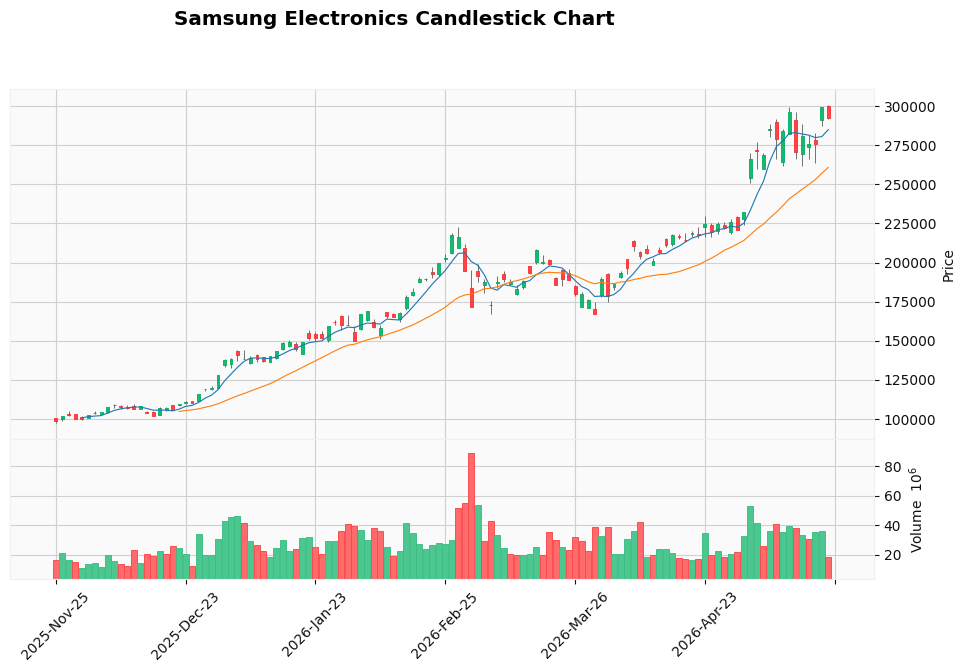

In [5]:
#최근 120일 데이터 기준으로 캔들차트 생성
recent_data = samsung.tail(120)

mpf.plot(
    recent_data,
    type="candle",
    mav=(5, 20),# 이동평균선 표시
    volume=True, #거래량 표시
    style="yahoo",
    figsize=(12, 7),
    title="Samsung Electronics Candlestick Chart"
)

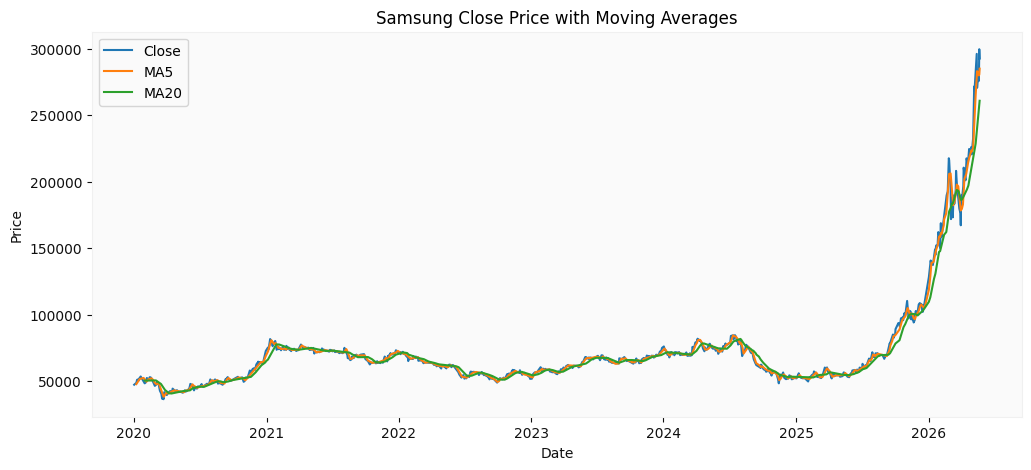

In [6]:
plt.figure(figsize=(12, 5))
#종가와 이동평균선 그래프 출력
plt.plot(samsung.index, samsung["Close"], label="Close")
plt.plot(samsung.index, samsung["MA5"], label="MA5")
plt.plot(samsung.index, samsung["MA20"], label="MA20")

plt.title("Samsung Close Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [9]:
# 뉴스 크롤링 + 감성분석
import pandas as pd #데이터프레임
import requests
from bs4 import BeautifulSoup
from urllib.parse import quote #한글 검색어 인코등


# 구글 뉴스 RSS 크롤링
def get_news_titles(keyword, max_news=10):#(검색할 키워드, 가져올 뉴스 개수)

    url = f"https://news.google.com/rss/search?q={quote(keyword)}&hl=ko&gl=KR&ceid=KR:ko"
#구글뉴스 검색
    response = requests.get(url)
#웹페이지 요청
    soup = BeautifulSoup(response.content, "xml")
#뉴스 제목 저장 리스트
    titles = []
#뉴스 제목을 추출하고 저장
    for item in soup.find_all("item")[:max_news]:
        titles.append(item.title.text)

    return titles


# 감성분석 함수
def sentiment_score(title):

    positive_words = [
        "상승", "호재", "성장", "최대", "증가", "강세", "개선",
        "돌파", "수혜", "기대", "회복", "실적", "흑자",
        "AI", "반등", "급등","1위"
    ]

    negative_words = [
        "하락", "악재", "감소", "부진", "약세", "위기", "적자",
        "우려", "급락", "손실", "감산", "불확실", "리스크","논란"
    ]
#초기 점수 0점
    score = 0
#긍정/부정 단어 저장 리스트
    found_positive = []
    found_negative = []
#긍정/부정 단어 포함 -> +1점
    for word in positive_words:
        if word in title:
            score += 1
            found_positive.append(word)

    for word in negative_words:
        if word in title:
            score -= 1
            found_negative.append(word)

    print("제목:", title)
    print("긍정 단어:", found_positive)
    print("부정 단어:", found_negative)
    print("최종 점수:", score)
    print()

    return score


# 삼성전자 뉴스 15개 가져오기
news_titles = get_news_titles("삼성전자", 15)


# 데이터프레임 생성
news_df = pd.DataFrame(news_titles, columns=["뉴스 제목"])


# 각 뉴스 제목에 감성 단어 분석
news_df["감성 점수"] = news_df["뉴스 제목"].apply(sentiment_score)


# 총점 계산
total_news_score = news_df["감성 점수"].sum()


# 결과 출력
print(news_df)

print("\n뉴스 감성 총점:", total_news_score)

if total_news_score > 0:
    print("전체적으로 긍정적인 뉴스가 더 많습니다.")

elif total_news_score < 0:
    print("전체적으로 부정적인 뉴스가 더 많습니다.")

else:
    print("긍정/부정이 뚜렷하지 않습니다.")


제목: [경제]삼성전자·하이닉스 레버리지 모레 상장..."고위험 주의" - YTN
긍정 단어: []
부정 단어: []
최종 점수: 0

제목: 삼성전자·하이닉스 두 배 추종 ETF 모레 출시 - MBC 뉴스
긍정 단어: []
부정 단어: []
최종 점수: 0

제목: 지난 한주 외국인 '삼성전자・SK하이닉스' 10조 순매도, 12거래일 연속 매도세 - 비즈니스포스트
긍정 단어: []
부정 단어: []
최종 점수: 0

제목: 삼성전자 DX 부문 동행노조 "찬반투표 중지 가처분" 예고 - MBC 뉴스
긍정 단어: []
부정 단어: []
최종 점수: 0

제목: 삼성전자, 세계 최초 '900단 V낸드' 구현…1000단 시대 초읽기 - 전자신문
긍정 단어: []
부정 단어: []
최종 점수: 0

제목: 1분기 주요 5대 낸드업체 매출 83.7%↑…삼성전자 1위 - v.daum.net
긍정 단어: ['1위']
부정 단어: []
최종 점수: 1

제목: 삼성전자, 1분기 낸드업체 매출 135.1억달러…빅5 중 1위 - 헤럴드경제
긍정 단어: ['1위']
부정 단어: []
최종 점수: 1

제목: 삼성전자 성과급 논란, 대만 TSMC에도 불똥 - 조선일보
긍정 단어: []
부정 단어: ['논란']
최종 점수: -1

제목: TSMC 직원들, 삼전 파업에 각성? 성과급 삭감설에 "파업할 때 됐다" - MBC 뉴스
긍정 단어: []
부정 단어: []
최종 점수: 0

제목: “파업 할 때가 왔다”…‘성과급 논란’ 삼성전자에 자극받은 이 회사 - 매일경제
긍정 단어: []
부정 단어: ['논란']
최종 점수: -1

제목: '총파업' 일단락 삼성전자, 2Q 영업익 85조 원 '역대 최고' 예약 - v.daum.net
긍정 단어: []
부정 단어: []
최종 점수: 0

제목: [단독] 삼성전자, 챗GPT·제미나이 사내 사용 전면 허용 추진 - 한겨레
긍정 단어: []
부정 단어: []
최종 점수: 0

제목: “불장은 왔는데 삼성전자만 산다?”...대형주만 북적인 코스피 -

In [10]:
samsung["News_Score"] = total_news_score
samsung["Tomorrow_Close"] = samsung["Close"].shift(-1)
#종가 데이터를 하루 앞으로 당겨서 오늘 정답값을 내일 종가로 설정

#예측에 사용할 변수들
features = [
    "Open", "High", "Low", "Close",
    "Volume", "MA5", "MA20", "News_Score"
]
#예측에 필요한 것만 선택하고 결측치 제거
data = samsung[features + ["Tomorrow_Close"]].dropna()

X = data[features] #사용할 변수
y = data["Tomorrow_Close"]#예측할 데이터, 내일 종가

print("예측용 데이터")
print(data.head())

예측용 데이터
                                   Open          High           Low  \
Date                                                                  
2020-01-31 00:00:00+09:00  49604.172651  50119.094858  48402.687500   
2020-02-03 00:00:00+09:00  47630.315129  49260.902494  47372.853966   
2020-02-04 00:00:00+09:00  49003.432519  50634.019591  48745.971403   
2020-02-05 00:00:00+09:00  51492.219013  51663.859743  50548.194997   
2020-02-06 00:00:00+09:00  51578.050078  52436.253906  51234.768547   

                                  Close    Volume           MA5          MA20  \
Date                                                                            
2020-01-31 00:00:00+09:00  48402.687500  19749457  50170.590625  50475.252734   
2020-02-03 00:00:00+09:00  49089.261719  23995260  49552.684375  50561.073633   
2020-02-04 00:00:00+09:00  50548.199219  21800192  49569.849219  50706.968555   
2020-02-05 00:00:00+09:00  51063.117188  19278165  49638.505469  50878.609375   
2020-02-

In [11]:
#학습 데이터와 테스트 데이터 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False#전체 데이터 중 20%를 테스트 용으로 사용, 데이터 섞지 않음
)
#선형회귀 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)
#테스트 데이터로 예측 수행
y_pred = model.predict(X_test)

print("모델 평가")
print("MAE:", mean_absolute_error(y_test, y_pred))#평균 오차
print("R2 Score:", r2_score(y_test, y_pred))#모델이 데이터를 얼마나 잘 설명하는지 나타내기

모델 평가
MAE: 2997.4122785472623
R2 Score: 0.9925217636180782


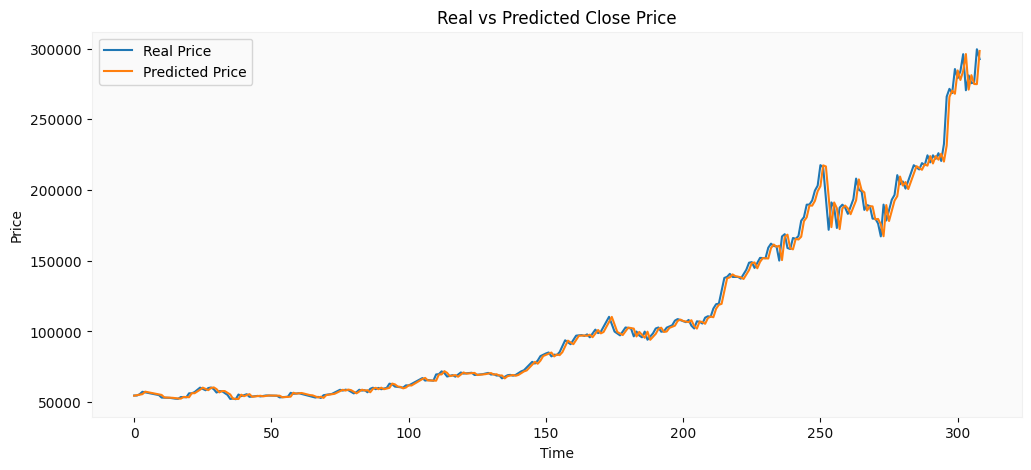

In [12]:
#실제 종가와 예측 종가 비교 그래프
plt.figure(figsize=(12, 5))

plt.plot(y_test.values, label="Real Price")
plt.plot(y_pred, label="Predicted Price")

plt.title("Real vs Predicted Close Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [14]:
#가장 최근 데이터로 내일 종가 예측
latest_data = samsung[features].dropna().iloc[-1:]
#학습된 모델로 내일 종가 예측
tomorrow_prediction = model.predict(latest_data)
#오늘 종가와 예측 종가 저장
today_close = latest_data["Close"].values[0]
predicted_close = tomorrow_prediction[0]
#예상 수익률 계산(예측종가-오늘종가)/오늘종가*100
expected_return = (predicted_close - today_close) / today_close * 100
#최종 예측 결과 출력
print("가장 최근 데이터")
print(latest_data)

print("\n삼성전자 내일 종가 예측값")
print(f"{predicted_close:,.0f}원")

print("\n예상 수익률")
print(f"{expected_return:.2f}%")
#예상 수익률 기준으로 상승/하락 판단
if expected_return > 0:
    print("모델은 내일 상승 가능성을 예측했습니다.")
elif expected_return < 0:
    print("모델은 내일 하락 가능성을 예측했습니다.")
else:
    print("큰 변화가 없을 것으로 예측했습니다.")

가장 최근 데이터
                               Open      High       Low     Close    Volume  \
Date                                                                          
2026-05-22 00:00:00+09:00  300000.0  300500.0  292000.0  292500.0  18395274   

                                MA5      MA20  News_Score  
Date                                                       
2026-05-22 00:00:00+09:00  284900.0  260750.0           2  

삼성전자 내일 종가 예측값
291,544원

예상 수익률
-0.33%
모델은 내일 하락 가능성을 예측했습니다.
